#Importing modules

In [161]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

In [162]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [163]:
!pip install kagglehub

In [164]:
import kagglehub
path = kagglehub.dataset_download("moodrammer/handdrawn-circuit-schematic-components")
print("Dataset path:", path)

Using Colab cache for faster access to the 'handdrawn-circuit-schematic-components' dataset.
Dataset path: /kaggle/input/handdrawn-circuit-schematic-components


In [165]:
import os
import shutil

source = path
target = "/content/dataset"

os.makedirs(target, exist_ok=True)

# The 'source' directory contains one subfolder: 'SolvaDataset_200_v3'
for item_in_source in os.listdir(source):
    item_path_in_source = os.path.join(source, item_in_source)

    # We expect 'item_in_source' to be 'SolvaDataset_200_v3' which is a directory
    if os.path.isdir(item_path_in_source):
        destination_path = os.path.join(target, item_in_source)

        # If the destination already exists, remove it before copying to avoid errors with copytree
        if os.path.exists(destination_path):
            shutil.rmtree(destination_path)

        # Copy the entire directory (e.g., 'SolvaDataset_200_v3') and its contents recursively
        shutil.copytree(item_path_in_source, destination_path)

#Dataset Loading

In [166]:
def load_dataset(root_dir):
    image_paths = []
    labels = []
    class_names = os.listdir(root_dir)

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(root_dir, class_name)
        for file in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, file))
            labels.append(label)

    return image_paths, labels, class_names

# Train Test Split

In [167]:
dataset_path = "/content/dataset/SolvaDataset_200_v3"
image_paths, labels, class_names = load_dataset(dataset_path)

X_train, X_test, y_train, y_test = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42
)
print(len(X_train), len(X_test))


2361 591


# Dataset Class

In [168]:
class CircuitDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128, 128))

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]
        return img, label

# Transformations

In [169]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor(),
])

## ============================
# Classical Methods (Baseline)
## ============================

## Template Matching

In [171]:
def template_predict(test_img, templates):
    best_score = -1
    best_label = None

    for label, template in templates.items():
        res = cv2.matchTemplate(test_img, template, cv2.TM_CCOEFF_NORMED)
        score = np.max(res)

        if score > best_score:
            best_score = score
            best_label = label

    return best_label

In [172]:
templates = {}

for i, path in enumerate(X_train):
    label = y_train[i]
    if label not in templates:
        templates[label] = cv2.imread(path, 0)

y_pred_tm = []

for path in X_test:
    img = cv2.imread(path, 0)
    pred = template_predict(img, templates)
    y_pred_tm.append(pred)

from sklearn.metrics import accuracy_score
tm_acc = accuracy_score(y_test, y_pred_tm)

print("Template Matching Accuracy:", tm_acc)

Template Matching Accuracy: 0.2182741116751269


## SIFT

In [174]:
sift = cv2.SIFT_create()

train_features = []
sift_train_labels = []

for i, path in enumerate(X_train):
    img = cv2.imread(path, 0)

    if img is None:
        continue

    kp, des = sift.detectAndCompute(img, None)

    if des is not None:
        train_features.append(des)
        sift_train_labels.append(y_train[i])

In [175]:
def sift_predict_fast(test_img, train_features, train_labels):
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(test_img, None)

    if des1 is None:
        return -1

    bf = cv2.BFMatcher()

    best_match = -1
    best_label = None

    for i, des2 in enumerate(train_features):

        if des2 is None:
            continue

        matches = bf.knnMatch(des1, des2, k=2)

        good = []
        for match_pair in matches:
            # Ensure there are two matches to unpack
            if len(match_pair) == 2:
                m, n = match_pair
                if m.distance < 0.75 * n.distance:
                    good.append(m)

        if len(good) > best_match:
            best_match = len(good)
            best_label = train_labels[i]

    return best_label

In [176]:
import cv2
from sklearn.metrics import accuracy_score

y_pred_sift = []

for path in X_test:
    img = cv2.imread(path, 0)

    if img is None:
        y_pred_sift.append(0)
        continue

    pred = sift_predict_fast(img, train_features, sift_train_labels)

    if pred is None or pred == -1:
        # Assign a default label, e.g., the majority class or 0
        pred = 0

    y_pred_sift.append(pred)

# Compute accuracy
sift_acc = accuracy_score(y_test, y_pred_sift)

print("SIFT Accuracy:", sift_acc)

SIFT Accuracy: 0.10152284263959391


# Dataset + DataLoader

In [177]:
train_dataset = CircuitDataset(X_train, y_train, transform)
test_dataset = CircuitDataset(X_test, y_test, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [178]:
dataset_path = "/content/dataset/SolvaDataset_200_v3"
image_paths, labels, class_names = load_dataset(dataset_path)
print("Total images:", len(image_paths))
print("Classes:", class_names)
print("Total Classes:", len(class_names))

Total images: 2952
Classes: ['dep_volt', 'cap', 'Ammeter', 'dc_volt_src_2', 'curr_src', 'dep_curr_src', 'battery', 'diode', 'dc_volt_src_1', 'ac_src', 'gnd_1', 'voltmeter', 'resistor', 'inductor', 'gnd_2']
Total Classes: 15


# ResNet18Model

In [179]:
class ResNet18Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet18(pretrained=True)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [180]:
def train_model(model, train_loader, val_loader, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model


In [181]:
def evaluate(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(y_true, y_pred))

    return y_true, y_pred

In [182]:
model = ResNet18Model(num_classes=len(class_names))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [183]:
model = train_model(model, train_loader, test_loader, epochs=40)

Epoch 1, Loss: 77.8956
Epoch 2, Loss: 28.1726
Epoch 3, Loss: 18.8396
Epoch 4, Loss: 13.0148
Epoch 5, Loss: 12.1584
Epoch 6, Loss: 11.6447
Epoch 7, Loss: 10.0844
Epoch 8, Loss: 10.0577
Epoch 9, Loss: 8.1263
Epoch 10, Loss: 7.4449
Epoch 11, Loss: 6.6528
Epoch 12, Loss: 6.5075
Epoch 13, Loss: 5.8712
Epoch 14, Loss: 5.2545
Epoch 15, Loss: 4.9932
Epoch 16, Loss: 4.4078
Epoch 17, Loss: 4.1682
Epoch 18, Loss: 4.6965
Epoch 19, Loss: 4.0639
Epoch 20, Loss: 3.9324
Epoch 21, Loss: 3.3885
Epoch 22, Loss: 4.5181
Epoch 23, Loss: 3.8255
Epoch 24, Loss: 3.1945
Epoch 25, Loss: 3.4985
Epoch 26, Loss: 2.7461
Epoch 27, Loss: 3.2166
Epoch 28, Loss: 2.4935
Epoch 29, Loss: 2.3651
Epoch 30, Loss: 3.9860
Epoch 31, Loss: 4.0806
Epoch 32, Loss: 4.0628
Epoch 33, Loss: 2.6952
Epoch 34, Loss: 3.0156
Epoch 35, Loss: 2.5879
Epoch 36, Loss: 2.6151
Epoch 37, Loss: 1.9694
Epoch 38, Loss: 3.1145
Epoch 39, Loss: 2.9609
Epoch 40, Loss: 2.1921


In [184]:
y_true, y_pred = evaluate(model, test_loader)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.95      0.98        42
           2       0.98      1.00      0.99        52
           3       0.94      1.00      0.97        31
           4       0.97      0.97      0.97        38
           5       1.00      0.97      0.99        37
           6       1.00      0.98      0.99        47
           7       1.00      1.00      1.00        46
           8       0.90      0.95      0.92        38
           9       0.97      0.90      0.93        31
          10       1.00      1.00      1.00        32
          11       1.00      0.97      0.99        38
          12       0.98      1.00      0.99        45
          13       1.00      1.00      1.00        39
          14       1.00      1.00      1.00        32

    accuracy                           0.98       591
   macro avg       0.98      0.98      0.98       591
weighted avg       0.98   

In [185]:
from sklearn.metrics import accuracy_score

cnn_acc = accuracy_score(y_true, y_pred)
print("CNN Accuracy:", cnn_acc)

CNN Accuracy: 0.9813874788494078


# YOLO

In [186]:
!pip install ultralytics

In [187]:
import os
import shutil
from sklearn.model_selection import train_test_split

source = "/content/dataset/SolvaDataset_200_v3"
target = "/content/yolo_dataset"

for cls in os.listdir(source):
    cls_path = os.path.join(source, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for split, files in zip(["train", "val"], [train_imgs, val_imgs]):
        split_dir = os.path.join(target, split, cls)
        os.makedirs(split_dir, exist_ok=True)

        for f in files:
            shutil.copy(os.path.join(cls_path, f), os.path.join(split_dir, f))

In [188]:
from ultralytics import YOLO

model_yolo = YOLO("yolov8n-cls.pt")

model_yolo.train(
    data="/content/yolo_dataset",
    epochs=20,
    imgsz=128
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5a0ad02e40>
curves: []
curves_results: []
fitness: 0.9890572428703308
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9781144857406616, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9890572428703308}
save_dir: PosixPath('/content/runs/classify/train7')
speed: {'preprocess': 0.06311863803710226, 'inference': 0.5851635622840649, 'loss': 0.00034450168283056524, 'postprocess': 0.00044799663105596214}
top1: 0.9781144857406616
top5: 1.0

In [189]:
metrics = model_yolo.val()

yolo_acc = metrics.top1
print("YOLO Accuracy:", yolo_acc)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,454,095 parameters, 0 gradients, 3.3 GFLOPs
train: /content/yolo_dataset/train... found 2358 images in 15 classes ✅ 
val: /content/yolo_dataset/val... found 594 images in 15 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 593.1±204.2 MB/s, size: 15.1 KB)
val: Scanning /content/yolo_dataset/val... 594 images, 0 corrupt: 100% ━━━━━━━━━━━━ 594/594 207.6Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 38/38 45.3it/s 0.8s
                   all      0.978          1
Speed: 0.0ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val5
YOLO Accuracy: 0.9781144857406616


In [190]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    return acc, precision, recall, f1

In [191]:
from ultralytics import YOLO
import os
import cv2

model = YOLO("runs/classify/train/weights/best.pt")

y_pred_yolo = []
y_true_yolo = []

val_path = "/content/yolo_dataset/val"

class_names = sorted(os.listdir(val_path))

for label, cls in enumerate(class_names):
    cls_path = os.path.join(val_path, cls)

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        results = model(img_path)
        pred = results[0].probs.top1

        y_pred_yolo.append(pred)
        y_true_yolo.append(label)


image 1/1 /content/yolo_dataset/val/Ammeter/92.bmp: 128x128 Ammeter 0.99, dc_volt_src_1 0.01, voltmeter 0.00, inductor 0.00, ac_src 0.00, 2.4ms
Speed: 1.2ms preprocess, 2.4ms inference, 0.1ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/yolo_dataset/val/Ammeter/88.bmp: 128x128 Ammeter 0.77, voltmeter 0.17, dc_volt_src_1 0.05, ac_src 0.01, curr_src 0.00, 3.3ms
Speed: 2.1ms preprocess, 3.3ms inference, 0.0ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/yolo_dataset/val/Ammeter/44.bmp: 128x128 Ammeter 1.00, ac_src 0.00, inductor 0.00, curr_src 0.00, voltmeter 0.00, 2.4ms
Speed: 1.0ms preprocess, 2.4ms inference, 0.0ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/yolo_dataset/val/Ammeter/30.bmp: 128x128 Ammeter 1.00, dc_volt_src_1 0.00, ac_src 0.00, inductor 0.00, voltmeter 0.00, 2.6ms
Speed: 1.5ms preprocess, 2.6ms inference, 0.0ms postprocess per image at shape (1, 3, 128, 128)

image 1/1 /content/yolo_dataset/val/Amme

In [192]:
tm_acc, tm_prec, tm_rec, tm_f1 = get_metrics(y_test, y_pred_tm)
sift_acc, sift_prec, sift_rec, sift_f1 = get_metrics(y_test, y_pred_sift)
cnn_acc, cnn_prec, cnn_rec, cnn_f1 = get_metrics(y_true, y_pred)
yolo_acc, yolo_prec, yolo_rec, yolo_f1 = get_metrics(y_true_yolo, y_pred_yolo)

In [193]:
print("\n=== FINAL MODEL COMPARISON ===\n")

print(f"{'Model':<20}{'Accuracy':<10}{'Precision':<10}{'Recall':<10}{'F1-score'}")
print("-"*60)

print(f"{'Template Matching':<20}{tm_acc:.3f}     {tm_prec:.3f}     {tm_rec:.3f}     {tm_f1:.3f}")
print(f"{'SIFT':<20}{sift_acc:.3f}     {sift_prec:.3f}     {sift_rec:.3f}     {sift_f1:.3f}")
print(f"{'CNN (ResNet18)':<20}{cnn_acc:.3f}     {cnn_prec:.3f}     {cnn_rec:.3f}     {cnn_f1:.3f}")
print(f"{'YOLOv8':<20}{yolo_acc:.3f}     {yolo_prec:.3f}     {yolo_rec:.3f}     {yolo_f1:.3f}")


=== FINAL MODEL COMPARISON ===

Model               Accuracy  Precision Recall    F1-score
------------------------------------------------------------
Template Matching   0.218     0.229     0.218     0.218
SIFT                0.102     0.309     0.102     0.104
CNN (ResNet18)      0.981     0.982     0.981     0.981
YOLOv8              0.968     0.968     0.968     0.968


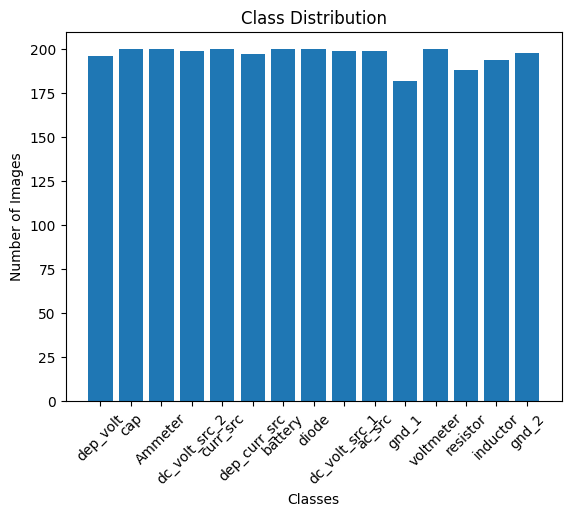

In [194]:
import matplotlib.pyplot as plt
import os

dataset_path = "/content/dataset/SolvaDataset_200_v3"

class_counts = {}
for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

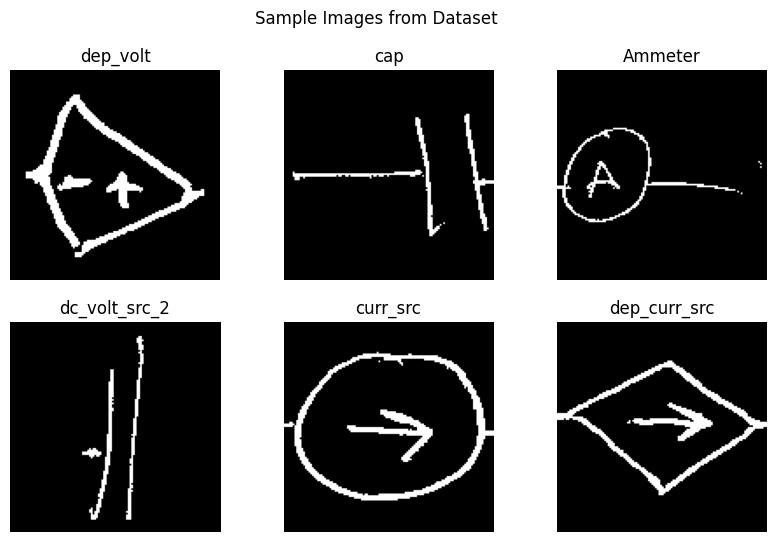

In [195]:
import cv2
import random

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(os.listdir(dataset_path)[:6]):
    class_folder = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(class_name)
    plt.axis('off')

plt.suptitle("Sample Images from Dataset")
plt.show()

In [196]:
sizes = []

for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            sizes.append(img.shape[:2])

sizes = list(set(sizes))
print("Unique image sizes:", sizes)

Unique image sizes: [(120, 120)]


In [197]:
for k, v in class_counts.items():
    print(f"{k}: {v}")

dep_volt: 196
cap: 200
Ammeter: 200
dc_volt_src_2: 199
curr_src: 200
dep_curr_src: 197
battery: 200
diode: 200
dc_volt_src_1: 199
ac_src: 199
gnd_1: 182
voltmeter: 200
resistor: 188
inductor: 194
gnd_2: 198


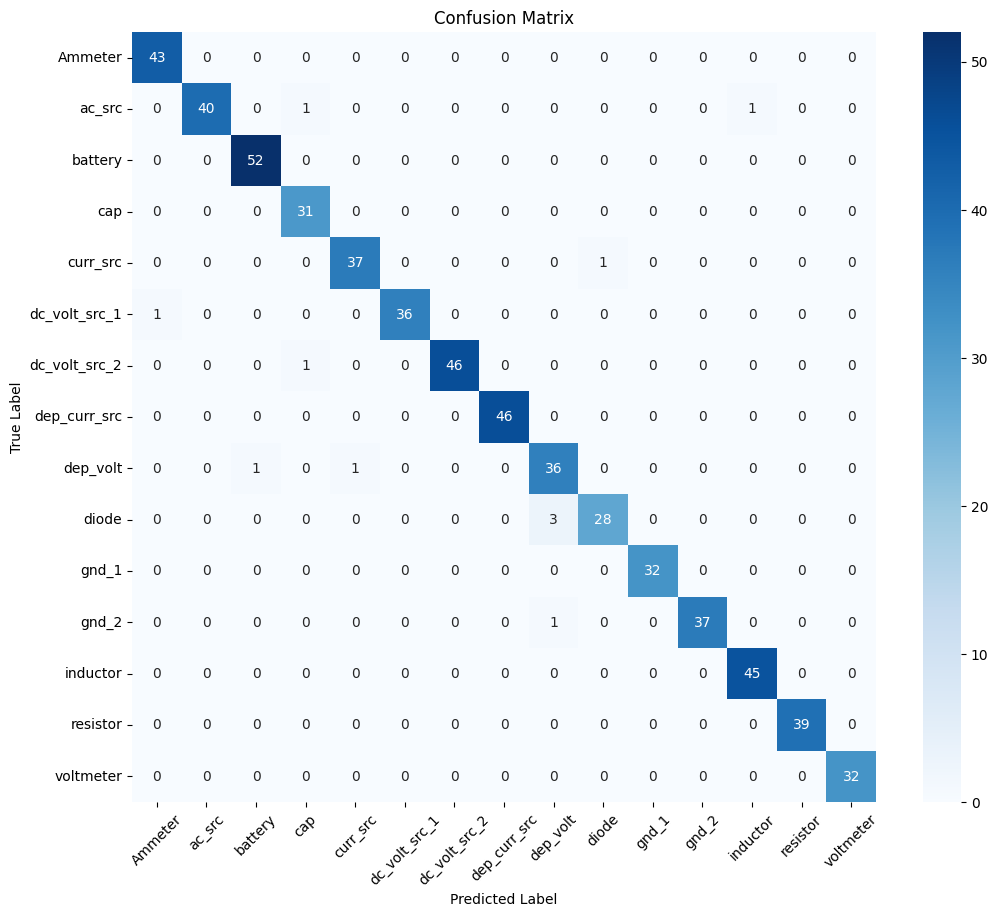

In [198]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()